# 01_data.ipynb — Data Exploration and Validation

**Purpose:** Load all 32 DEAP subjects, validate shapes and label ranges, inspect raw EEG signal and PSD for sanity, save unified arrays to `results/` for downstream notebooks.

**Outputs saved:** `X_eeg.npy`, `X_peripheral.npy`, `y.npy`, `subject_ids.npy`

Run cells in order. Do not skip validation cells.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import welch

from loader import load_subject, load_all, FS, BASELINE_SAMPLES, N_SIGNAL_SAMPLES
from features import CHANNEL_NAMES, BANDS

Path('../results').mkdir(exist_ok=True)
Path('../results/figures').mkdir(exist_ok=True)

## 1. Inspect a single subject before running load_all
Manually load s01.dat and verify baseline correction is working before touching the full dataset.

In [2]:
eeg, peripheral, labels = load_subject('../data/s01.dat')

print(f"EEG shape:        {eeg.shape}        — expected (40, 32, 7680)")
print(f"Peripheral shape: {peripheral.shape}  — expected (40, 8, 7680)")
print(f"Labels shape:     {labels.shape}      — expected (40, 4)")
print(f"\nEEG value range:  [{eeg.min():.2f}, {eeg.max():.2f}] µV  — expect roughly -50 to +50")
print(f"Any NaN: {np.isnan(eeg).any()} | Any Inf: {np.isinf(eeg).any()}")

EEG shape:        (40, 32, 7680)        — expected (40, 32, 7680)
Peripheral shape: (40, 8, 7680)  — expected (40, 8, 7680)
Labels shape:     (40, 4)      — expected (40, 4)

EEG value range:  [-93.12, 126.13] µV  — expect roughly -50 to +50
Any NaN: False | Any Inf: False


In [3]:
# Verify baseline correction: first few samples of each trial should be near zero
# (not exactly zero — correction subtracts the mean, residual variance remains)
trial_0_ch0_mean = eeg[0, 0, :10].mean()
print(f"Trial 0, Ch 0, first 10 samples mean: {trial_0_ch0_mean:.4f}")
print(f"Trial 0, Ch 0, last  10 samples mean: {eeg[0, 0, -10:].mean():.4f}")
print("\nLabel columns: [valence, arousal, dominance, liking]")
print(labels[:5])

Trial 0, Ch 0, first 10 samples mean: -4.6266
Trial 0, Ch 0, last  10 samples mean: 0.0731

Label columns: [valence, arousal, dominance, liking]
[[1.29 1.4  6.9  7.83]
 [0.9  1.69 7.28 8.47]
 [0.42 1.46 9.   7.08]
 [4.94 6.01 6.12 8.06]
 [6.96 3.92 7.19 6.05]]


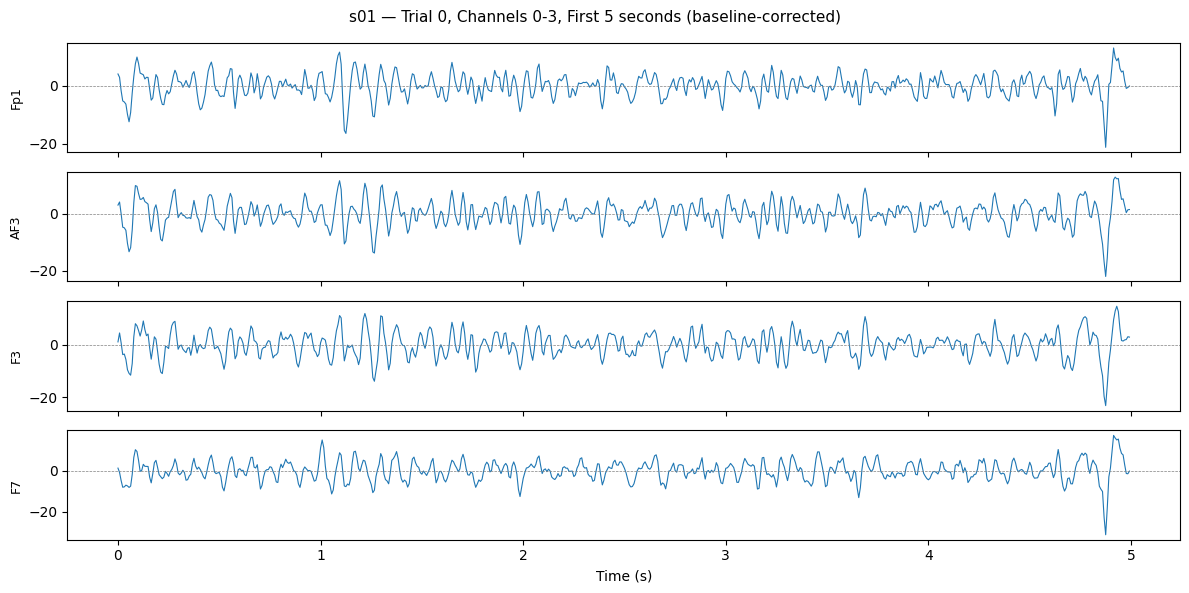

In [4]:
# Plot raw EEG traces for trial 0, first 4 electrodes, first 5 seconds
n_seconds = 5
n_samples  = n_seconds * FS
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

for i, ax in enumerate(axes):
    t = np.arange(n_samples) / FS
    ax.plot(t, eeg[0, i, :n_samples], linewidth=0.8)
    ax.set_ylabel(CHANNEL_NAMES[i], fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[-1].set_xlabel('Time (s)')
fig.suptitle('s01 — Trial 0, Channels 0-3, First 5 seconds (baseline-corrected)', fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/raw_eeg_trace.png', dpi=150)
plt.show()

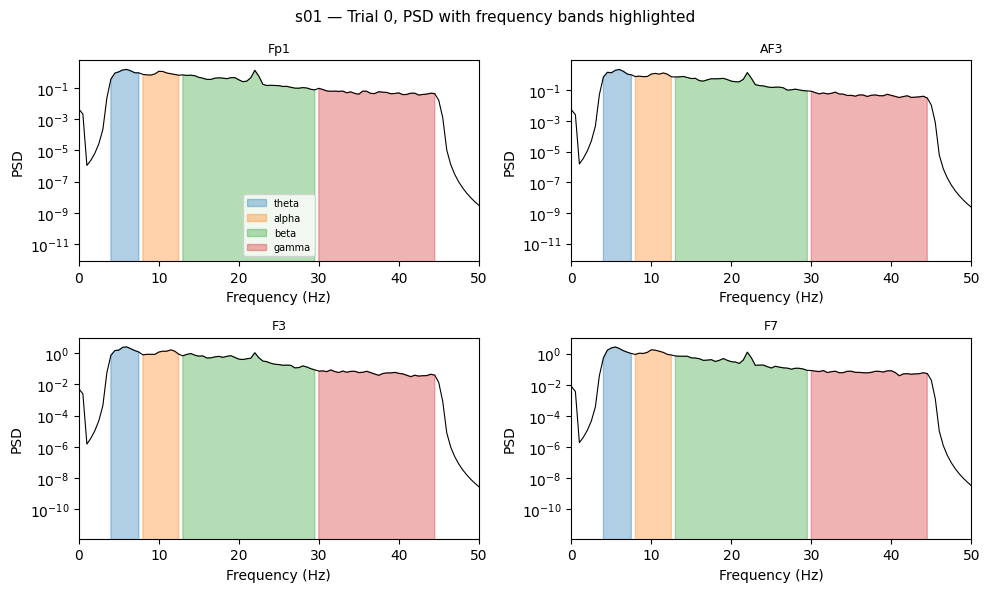

In [5]:
# Plot PSD for trial 0, first 4 electrodes — confirm band structure is visible
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
band_colors = {'theta': 'C0', 'alpha': 'C1', 'beta': 'C2', 'gamma': 'C3'}

for i, ax in enumerate(axes.flat):
    freqs, psd = welch(eeg[0, i], fs=FS, nperseg=256, noverlap=128)
    ax.semilogy(freqs, psd, color='black', linewidth=0.8)
    for band, (low, high) in BANDS.items():
        mask = (freqs >= low) & (freqs < high)
        ax.fill_between(freqs[mask], psd[mask], alpha=0.35,
                        color=band_colors[band], label=band)
    ax.set_title(CHANNEL_NAMES[i], fontsize=9)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_xlim(0, 50)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('s01 — Trial 0, PSD with frequency bands highlighted', fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/psd_bands.png', dpi=150)
plt.show()

## 2. Load all 32 subjects

In [6]:
X_eeg, X_peripheral, y, subject_ids = load_all('../data')

# Confirm shapes
assert X_eeg.shape        == (1280, 32, 7680)
assert X_peripheral.shape == (1280, 8,  7680)
assert y.shape            == (1280, 4)
assert subject_ids.shape  == (1280,)
print("Shape assertions passed.")

Loaded 32 subjects | 1280 trials | EEG shape: (1280, 32, 7680)
     valence: min=0.0  max=9.0  mean=3.47  median=3.1
     arousal: min=0.0  max=9.0  mean=3.73  median=3.3
   dominance: min=1.0  max=9.0  mean=5.38  median=5.2
      liking: min=1.0  max=9.0  mean=5.52  median=6.0
Shape assertions passed.


In [7]:
# Confirm trial count per subject is exactly 40
unique, counts = np.unique(subject_ids, return_counts=True)
assert (counts == 40).all(), f"Unequal trial counts: {dict(zip(unique, counts))}"
print(f"Subjects: {len(unique)} | Trials per subject: {counts[0]} (uniform)")

Subjects: 32 | Trials per subject: 40 (uniform)


In [8]:
# Label distribution — note valence/arousal medians below scale midpoint (known DEAP characteristic)
dim_names = ['valence', 'arousal', 'dominance', 'liking']
print(f"{'Dimension':<12} {'min':>5} {'max':>5} {'mean':>6} {'median':>7} {'std':>6}")
print('-' * 45)
for i, name in enumerate(dim_names):
    col = y[:, i]
    print(f"{name:<12} {col.min():>5.2f} {col.max():>5.2f} "
          f"{col.mean():>6.2f} {np.median(col):>7.2f} {col.std():>6.2f}")

# Flag sub-1 values (rating boundary artifacts)
for i, name in enumerate(dim_names):
    n_below = (y[:, i] < 1.0).sum()
    if n_below > 0:
        print(f"\n[NOTE] {name}: {n_below} trials with rating < 1.0 (boundary artifact, document in paper)")

Dimension      min   max   mean  median    std
---------------------------------------------
valence       0.00  9.00   3.47    3.08   2.01
arousal       0.00  9.00   3.73    3.31   1.98
dominance     1.00  9.00   5.38    5.24   2.10
liking        1.00  9.00   5.52    6.05   2.28

[NOTE] valence: 110 trials with rating < 1.0 (boundary artifact, document in paper)

[NOTE] arousal: 53 trials with rating < 1.0 (boundary artifact, document in paper)


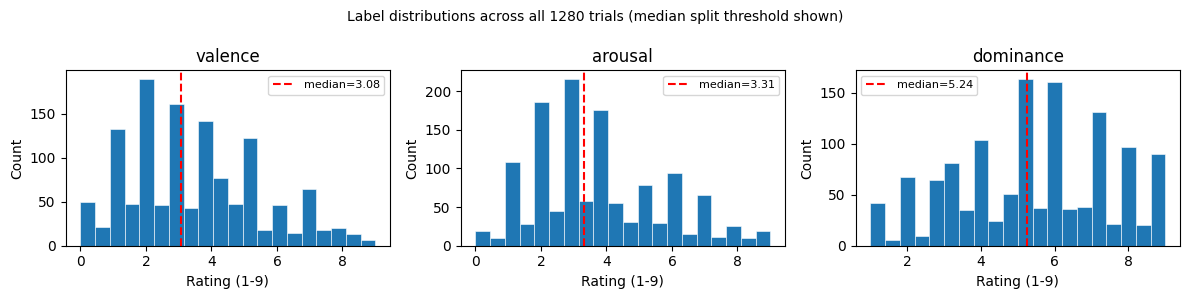

In [9]:
# Label histograms across all 1280 trials
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, (ax, name) in enumerate(zip(axes, ['valence', 'arousal', 'dominance'])):
    ax.hist(y[:, i], bins=20, edgecolor='white', linewidth=0.4)
    ax.axvline(np.median(y[:, i]), color='red', linewidth=1.5,
               linestyle='--', label=f'median={np.median(y[:,i]):.2f}')
    ax.set_title(name)
    ax.set_xlabel('Rating (1-9)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Label distributions across all 1280 trials (median split threshold shown)', fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/label_distributions.png', dpi=150)
plt.show()

## 3. Save to results/

In [10]:
np.save('../results/X_eeg.npy',        X_eeg)
np.save('../results/X_peripheral.npy', X_peripheral)
np.save('../results/y.npy',            y)
np.save('../results/subject_ids.npy',  subject_ids)

print("Saved:")
for name in ['X_eeg', 'X_peripheral', 'y', 'subject_ids']:
    path = Path(f'../results/{name}.npy')
    print(f"  {path}  ({path.stat().st_size / 1e6:.1f} MB)")

Saved:
  ../results/X_eeg.npy  (2516.6 MB)
  ../results/X_peripheral.npy  (629.1 MB)
  ../results/y.npy  (0.0 MB)
  ../results/subject_ids.npy  (0.0 MB)
